# TC1 - Introdução ao Reconhecimento de Padrões (TI0097)

Nome: Nataniel Marques Viana Neto

Mátricula: 554664

Trabalho computacional sobre a base Wall Following Robot Navigation Data. Na Questão 1 é feita uma análise descritiva usando o arquivo com 4 atributos (sensor_readings_4.data) e na Questão 2 os classificadores são avaliados no problema reduzido a 3 classes, removendo a classe minoritária Slight-Left-Turn.

## Bibliotecas

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import cdist
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import time
from pathlib import Path
import urllib.request

sns.set_style("whitegrid")
np.random.seed(42)

## Dados

In [3]:
BASE = "https://github.com/NatanielMarques14/trabalhos-computacionais-reconhecimento-padroes/releases/download/v1.0"

arquivos = [
    "sensor_readings_4.data",
    "sensor_readings_2.data",
    "sensor_readings_24.data",
    "Wall-following.names"
]

for arq in arquivos:
    if not Path(arq).exists():
        urllib.request.urlretrieve(f"{BASE}/{arq}", arq)

## Questão 1 - Análise estatística dos dados

Carregando o arquivo com os 4 atributos simplificados (distância frontal, esquerda, direita e traseira).

In [4]:
colunas = ["SD_front", "SD_left", "SD_right", "SD_back", "Classe"]
df = pd.read_csv("sensor_readings_4.data", header=None, names=colunas)
atributos = colunas[:-1] # pegamos todos os elementos da lista, exceto o último (classe)
df.head()

,SD_front,SD_left,SD_right,SD_back,Classe
0,1.687,0.445,2.332,0.429,Slight-Right-Turn
1,1.687,0.449,2.332,0.429,Slight-Right-Turn
2,1.687,0.449,2.334,0.429,Slight-Right-Turn
3,1.687,0.449,2.334,0.429,Slight-Right-Turn
4,1.687,0.449,2.334,0.429,Slight-Right-Turn


### (i) Número de classes e instâncias por classe


In [5]:
contagem = df["Classe"].value_counts()
print("Número de classes:", df["Classe"].nunique())
contagem

Número de classes: 4


Classe
Move-Forward         2205
Sharp-Right-Turn     2097
Slight-Right-Turn     826
Slight-Left-Turn      328
Name: count, dtype: int64

A base tem 4 classes, cada uma correspondendo a um comando de movimento do robô. São elas: Move-Forward, Sharp-Right-Turn, Slight-Right-Turn e Slight-Left-Turn. As classes têm respectivamente: 2205, 2097, 826 e 328 instâncias. Ou seja, temos 5456 instâncias no total.

### (ii) Média, variância, assimetria e curtose por classe

Fazendo os cálculos separados por classe para cada um dos 4 atributos.

In [6]:
estatisticas = df.groupby("Classe")[atributos].agg(["mean", "var", "skew"]) # atributos é a lista de colunas que pegamos que não inclui a coluna de classe
# as funções do agrupamento trabalham com cada coluna separadamente, então o resultado de cada métrica é calculado dentro os elementos de cada coluna, e não entre colunas diferentes

def curtose(x):
    return stats.kurtosis(x)

curtoses = df.groupby("Classe")[atributos].agg(curtose)
curtoses.columns = pd.MultiIndex.from_product([atributos, ["kurtosis"]]) # estatisticas de curtose não são calculadas pelo método agg, então precisamos criar um multiindex para a coluna de curtose

pd.concat([estatisticas, curtoses], axis=1).sort_index(axis=1)

SD_back                                SD_front  \
                    kurtosis      mean      skew       var  kurtosis   
Classe                                                                 
Move-Forward       17.135170  1.080591  3.318200  0.341457  1.943839   
Sharp-Right-Turn    3.247686  1.434310  1.933195  1.121251  4.080101   
Slight-Left-Turn   10.299400  2.153622  1.876293  0.206765 -1.284144   
Slight-Right-Turn  -0.175661  1.031969 -0.299419  0.090603  8.103239   

                                                   SD_left            \
                       mean      skew       var   kurtosis      mean   
Classe                                                                 
Move-Forward       1.584937  1.467565  0.467914  -0.942694  0.652264   
Sharp-Right-Turn   0.799622 -1.827464  0.005397  78.967451  0.663477   
Slight-Left-Turn   1.456259  0.056162  0.105220   4.923948  1.563058   
Slight-Right-Turn  1.683617  2.172875  0.281631   1.233756  0.453715   

                                       SD_right                                
                       skew       var  kurtosis      mean      skew       var  
Classe                                                                         
Move-Forward       0.168904  0.008977  0.693613  1.863251  1.163584  0.283098  
Sharp-Right-Turn   7.770467  0.109105 -0.520000  1.912139  0.669554  0.448719  
Slight-Left-Turn   1.578531  0.275643  0.293983  1.632399  0.513797  0.098313  
Slight-Right-Turn -1.484722  0.001609  7.753439  1.953452  1.996049  0.123944

### (iii) Histogramas dos atributos

Um histograma por atributo, separando as classes por cor para ver como a densidade de cada uma se distribui.

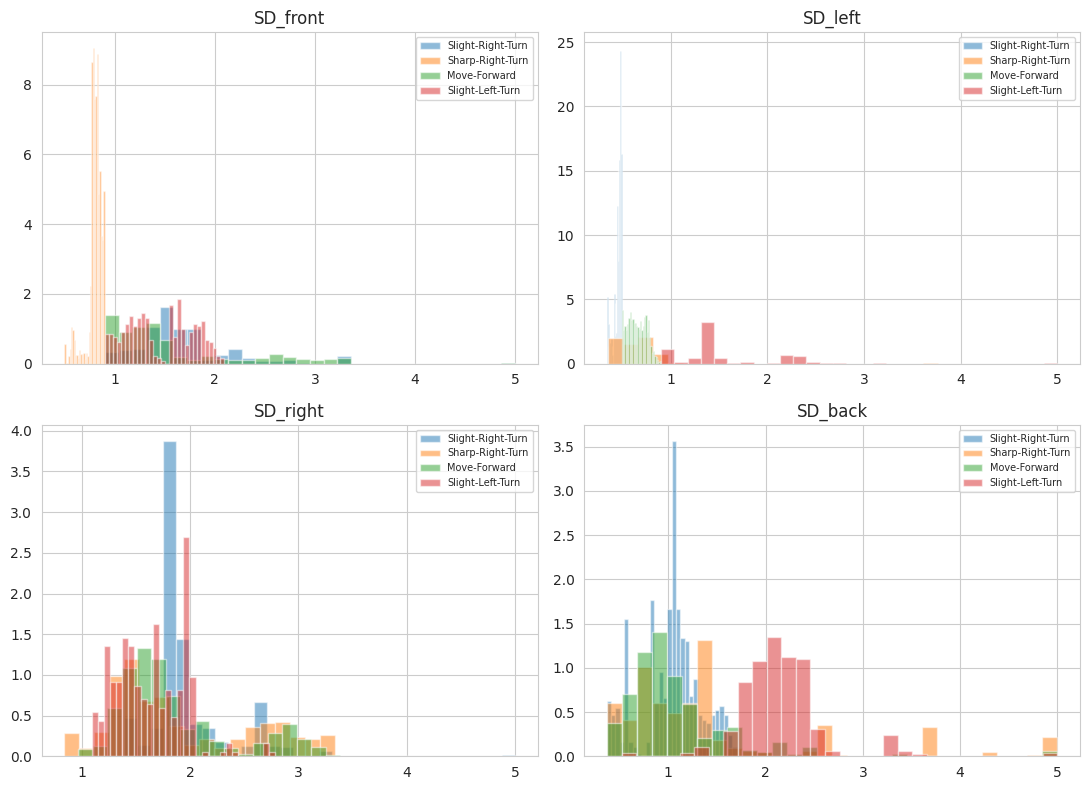

In [7]:
fig, eixos = plt.subplots(2, 2, figsize=(11, 8))
for eixo, atributo in zip(eixos.ravel(), atributos):
    for classe in df["Classe"].unique():
        dados = df.loc[df["Classe"] == classe, atributo]
        eixo.hist(dados, bins=30, alpha=0.5, label=classe, density=True)
    eixo.set_title(atributo)
    eixo.legend(fontsize=7)
plt.tight_layout()
plt.show()

Os histogramas mostram a distribuição dos valores dos quatro sensores (atributos) (`SD_front`, `SD_left`, `SD_right` e `SD_back`) para cada uma das quatro classes de movimento do robô. Como foi utilizada a opção `density=True`, a altura das barras representa uma estimativa da densidade de probabilidade, permitindo comparar o formato das distribuições entre as diferentes classes independentemente da quantidade de instâncias, ou seja, quanto maior a barra, mais comum é achar aquele valor daquele intervalo. O eixo X mostra os valores que aquele determinado sensor mediu, como por exemplo, o gráfico do SD_right temos valores como 1.0, 1.5, 2.0, 2.5 e 3.0.


De modo geral, observa-se que existe uma considerável sobreposição entre as distribuições das classes, indicando que um único atributo, isoladamente, não é suficiente para separar perfeitamente todos os movimentos.

No atributo **SD_front**, a classe **Sharp-Right-Turn** concentra a maior parte das observações em valores mais baixos (próximos de 0,8), enquanto as demais classes apresentam distribuições mais espalhadas e parcialmente sobrepostas. A classe **Move-Forward** é a que apresenta maior dispersão, alcançando valores superiores a 3,0.

O atributo **SD_left** é o que demonstra a separação visual mais evidente entre algumas classes. A classe **Slight-Right-Turn** concentra-se fortemente em valores baixos, enquanto **Slight-Left-Turn** apresenta valores predominantemente mais altos, sugerindo que esse sensor possui boa capacidade discriminativa para esses movimentos.

No caso de **SD_right**, todas as classes apresentam distribuições bastante concentradas entre aproximadamente 1,5 e 2,5, com forte sobreposição. Embora existam pequenas diferenças na forma das distribuições e na dispersão, esse atributo, isoladamente, oferece menor poder de distinção entre as classes.

Por fim, o atributo **SD_back** também apresenta sobreposição entre as distribuições, porém nota-se que a classe **Slight-Left-Turn** tende a assumir valores mais elevados que as demais, enquanto **Slight-Right-Turn** concentra-se em valores menores. Além disso, observa-se a presença de alguns valores extremos, principalmente na classe **Sharp-Right-Turn**, indicando a existência de poucas observações distantes da maior parte dos dados.

De forma geral, a análise visual indica que nenhum dos sensores é suficiente, sozinho, para classificar perfeitamente os movimentos do robô. Entretanto, alguns atributos, especialmente **SD_left** e **SD_back**, apresentam padrões que podem contribuir significativamente para a diferenciação entre as classes quando utilizados em conjunto em um modelo de classificação.

### (iv) Scatterplot map dos pares de atributos

Colocando todas as combinações de pares para enxergar visualmente se existe alguma relação entre os atributos.

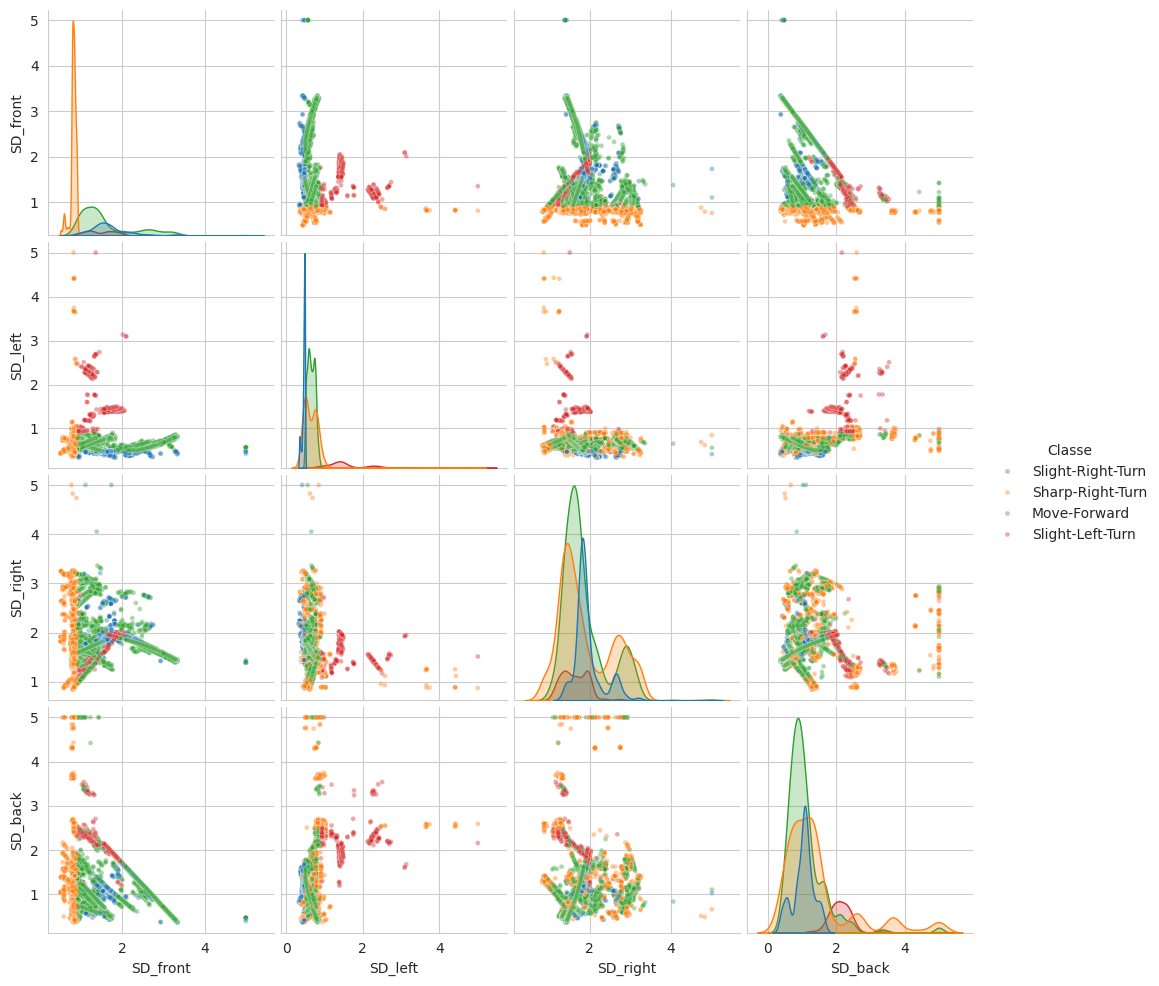

In [8]:
sns.pairplot(df, hue="Classe", vars=atributos, plot_kws={"alpha": 0.4, "s": 12})
plt.show()

O gráfico de pares (*pairplot*) permite analisar simultaneamente a distribuição individual de cada atributo e o relacionamento entre todos os pares de atributos, considerando as quatro classes de movimento do robô. Na diagonal principal são apresentadas as distribuições de densidade de cada atributo, enquanto as demais posições mostram gráficos de dispersão entre dois atributos distintos, possibilitando identificar padrões, correlações e possíveis regiões de separação entre as classes.

De maneira geral, observa-se que existe uma considerável sobreposição entre as classes, indicando que a tarefa de classificação não é trivial e que dificilmente um único atributo é suficiente para distinguir perfeitamente todos os movimentos do robô. Ainda assim, algumas combinações de atributos apresentam agrupamentos mais definidos, sugerindo que a utilização conjunta das informações pode aumentar o poder de discriminação dos modelos de classificação.

As distribuições na diagonal mostram que os atributos **SD_right** e **SD_back** apresentam maior dispersão dos valores, enquanto **SD_left** e **SD_front** possui valores mais concentrados em faixas menores. O atributo **SD_right** concentra grande parte das observações entre aproximadamente 1,5 e 2,5, embora ainda apresente sobreposição entre as classes.

Nos gráficos de dispersão também é possível observar relações entre alguns atributos. Em combinações envolvendo **SD_front** e **SD_back**, nota-se uma tendência de relação inversa em parte das observações, enquanto outras combinações apresentam nuvens de pontos mais espalhadas, sem uma relação linear evidente. Além disso, algumas classes ocupam regiões específicas do espaço de atributos, porém essas regiões frequentemente se sobrepõem às das demais classes.

De forma geral, o *pairplot* reforça que os atributos possuem comportamento distinto entre as classes, mas também evidencia uma significativa interseção entre elas. Essa análise está de acordo com a natureza do conjunto de dados, no qual a tarefa de navegação do robô não é linearmente separável, indicando que modelos capazes de explorar relações conjuntas entre os atributos tendem a apresentar melhor desempenho do que abordagens baseadas em um único atributo ou em separações lineares simples.

### (v) Matriz de correlação

Calculando a correlação de Pearson entre os 4 atributos e comparando com o que foi visto no scatterplot.

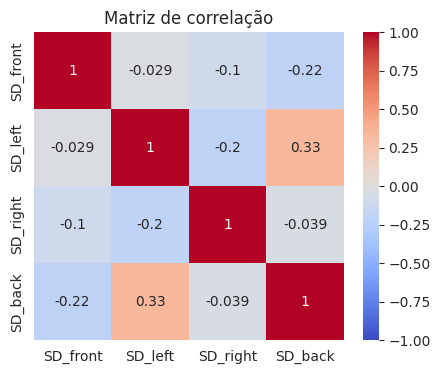

,SD_front,SD_left,SD_right,SD_back
SD_front,1.000000,-0.028617,-0.102938,-0.217564
SD_left,-0.028617,1.000000,-0.203957,0.331701
SD_right,-0.102938,-0.203957,1.000000,-0.039305
SD_back,-0.217564,0.331701,-0.039305,1.000000


In [9]:
matriz_corr = df[atributos].corr()
plt.figure(figsize=(5, 4))
sns.heatmap(matriz_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlação")
plt.show()
matriz_corr

A matriz confirma o que o scatterplot já sugeria, os valores de correlação são baixos ou moderados, sem nenhum par fortemente correlacionado. As maiores e menores (mais negativas) correlações ocorrem com o SD_back, sendo o SD_back com o SD_front a correlação mais negativa(-0.22), observamos isso também no scatterplot onde esses dois possuem uma visível distribuição diagonal descrescente semelhante a uma reta.

Enquanto isso, o SD_back com SD_left possuem a maior correlação positiva (0.33), observamos um pouco disso no scatterplot onde mesmo não tendo uma diagonal evidente como no caso do SD_back com o SD_front, conseguimos forçar uma reta imaginária diagonal crescente dos pontos. 

O restante das correlações do SD_front são perto de zero e isso se confirma pelas nuvens sem formato definido observadas no scatterplot. Os dois métodos são complementares e não equivalentes, a matriz dá o número exato de forma rápida mas o scatterplot mostra o formato da relação, por exemplo se ela é linear, se existe alguma curva ou se são pontos espalhados sem padrão algum, coisa que só o coeficiente de correlação sozinho não conta.

## Questão 2 - Classificação de padrões

O problema original tem 4 classes. Aqui a classe Slight-Left-Turn é removida por ser a minoritária e muito menos representada que as outras (menos de 6% das amostras), ficando o problema com as 3 classes restantes: Move-Forward, Slight-Right-Turn e Sharp-Right-Turn.

In [10]:
df3 = df[df["Classe"] != "Slight-Left-Turn"].reset_index(drop=True)
X = df3[atributos].values
y = df3["Classe"].values
classes = sorted(df3["Classe"].unique())
df3["Classe"].value_counts()

Classe
Move-Forward         2205
Sharp-Right-Turn     2097
Slight-Right-Turn     826
Name: count, dtype: int64

### Classificadores implementados

| Classificador | Descrição |
| :--- | :--- |
| Vizinho Mais Próximo (1-NN) | Classifica uma amostra com base na classe do seu vizinho mais próximo, utilizando a distância de Minkowski para diferentes valores de \(m\). |
| Distância Mínima ao Centróide | Atribui a classe cujo centróide (média das amostras da classe) está mais próximo da amostra de teste. |
| Distância Mínima ao Centróide (Robusto a Outliers) | Variante do método anterior que utiliza um centróide robusto, reduzindo a influência de valores discrepantes (outliers). |
| Máxima Correlação | Classifica a amostra de acordo com a classe que apresenta a maior correlação com o vetor de teste. |

### Metodologia de Implementação

Os classificadores serão implementados utilizando o conjunto de treinamento para construir seus modelos e, posteriormente, realizar previsões sobre o conjunto de teste. Para avaliar a robustez dos métodos, serão utilizadas diferentes proporções de divisão entre treinamento e teste, repetindo cada experimento 100 vezes com partições estratificadas.

### Distância de Minkowski

O classificador do Vizinho Mais Próximo (1-NN) utilizará a distância de Minkowski, definida por:

$
d(\mathbf{x},\mathbf{y})=
\left(
\sum_{i=1}^{n}|x_i-y_i|^m
\right)^{\frac{1}{m}}
$

onde:

- \(x_i\) e \(y_i\) representam os atributos das amostras;
- \(n\) é o número de atributos;
- \(m\) determina a ordem da distância.

Serão avaliados os valores:

$
m \in \{0.5,\;2/3,\;1,\;3/2,\;2,\;5/2\}
$

Após calcular a distância entre cada amostra de teste e todas as amostras de treinamento, a classe da amostra mais próxima será atribuída como resultado da classificação.

### Distância Mínima ao Centróide

Neste método, cada classe é representada por um centróide calculado pela média de seus vetores de treinamento:

$
\mathbf{m}_i=
\frac{1}{N_i}
\sum_{i=1}^{N_i}\mathbf{x}_i
$

em que \(N_i\) é o número de exemplos da i-ésima classe
(cujo rótulo é $\omega_i$), i = 1, . . . , C.

Durante a classificação, calcula-se a distância entre a amostra de teste e todos os centróides, sendo escolhida a classe correspondente ao centróide mais próximo.

### Centróide Robusto

A versão robusta substitui a média pela mediana de cada atributo:

$
\mathbf{m}_i=
\operatorname{mediana}(\mathbf{x}_1,\mathbf{x}_2,\ldots,\mathbf{x}_{i})
$

$
\forall X \in \omega_i
$

Essa estratégia reduz a influência de valores extremos (outliers), produzindo representantes mais estáveis para cada classe.

### Classificador por Máxima Correlação

O classificador MC nada mais é do que uma implementação
dos classificadores de distância mínima (NN ou DMC) em
que a medida de dissimilaridade é substituída por uma
medida de similaridade, no caso, o produto escalar.

Neste método, cada classe também é representada por um vetor protótipo. A decisão é realizada por meio do coeficiente de correlação entre a amostra de teste e cada protótipo:

$
r=
\frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}
{\sqrt{\sum_{i=1}^{n}(x_i-\bar{x})^2}
\sqrt{\sum_{i=1}^{n}(y_i-\bar{y})^2}}
$

A amostra é atribuída à classe cujo protótipo apresentar o maior valor de correlação.

### Avaliação dos Classificadores

Cada método será avaliado considerando:

- cinco proporções de treinamento (\(20\%\), \(30\%\), \(50\%\), \(70\%\) e \(80\%\));
- 100 repetições para cada proporção, utilizando particionamento estratificado;
- acurácia global;
- acurácia por classe;
- tempo de treinamento;
- tempo de classificação (teste);
- matrizes de confusão correspondentes ao melhor e ao pior desempenho de cada classificador.

### Implementação dos classificadores

Cada função de treino devolve o que o classificador precisa guardar junto com o tempo gasto, e cada função de previsão devolve os rótulos preditos junto com o tempo de teste.

In [11]:
def treinar_nn(X_train, y_train):
    t0 = time.perf_counter()
    tempo = time.perf_counter() - t0
    return (X_train, y_train), tempo

def prever_nn(modelo, X_test, p):
    X_train, y_train = modelo
    t0 = time.perf_counter()
    distancias = cdist(X_test, X_train, metric="minkowski", p=p)
    y_pred = y_train[np.argmin(distancias, axis=1)]
    tempo = time.perf_counter() - t0
    return y_pred, tempo

### Treinamento e predição

- **`treinar_nn`**: como o método do Vizinho Mais Próximo (1-NN) não realiza treinamento propriamente dito, a função apenas armazena os dados de treino e registra o tempo dessa etapa.

- **`prever_nn`**: calcula a distância de Minkowski entre cada amostra de teste e todas as amostras de treino, identifica o vizinho mais próximo e atribui sua classe como previsão, registrando também o tempo de execução.

In [12]:
def treinar_centroide(X_train, y_train, robusto=False):
    t0 = time.perf_counter()
    protos = {}
    for c in classes:
        Xc = X_train[y_train == c]
        protos[c] = np.median(Xc, axis=0) if robusto else np.mean(Xc, axis=0)
    tempo = time.perf_counter() - t0
    return protos, tempo

def prever_centroide(protos, X_test):
    t0 = time.perf_counter()
    nomes = list(protos.keys())
    M = np.array([protos[c] for c in nomes])
    distancias = cdist(X_test, M)
    y_pred = np.array(nomes)[np.argmin(distancias, axis=1)]
    tempo = time.perf_counter() - t0
    return y_pred, tempo

### Treinamento e predição

- **`treinar_centroide`**: calcula um vetor representativo (centróide) para cada classe utilizando a **média** das amostras ou, na versão robusta, a **mediana**, reduzindo a influência de outliers. Também registra o tempo de treinamento.

- **`prever_centroide`**: calcula a distância entre cada amostra de teste e os centróides das classes, atribuindo a classe correspondente ao centróide mais próximo e registrando o tempo de classificação.

In [13]:
def treinar_correlacao(X_train, y_train):
    t0 = time.perf_counter()
    protos = {c: X_train[y_train == c].mean(axis=0) for c in classes}
    tempo = time.perf_counter() - t0
    return protos, tempo

def prever_correlacao(protos, X_test):
    t0 = time.perf_counter()
    nomes = list(protos.keys())
    M = np.array([protos[c] for c in nomes])
    Mc = M - M.mean(axis=1, keepdims=True)
    Xc = X_test - X_test.mean(axis=1, keepdims=True)
    numerador = Xc @ Mc.T
    denominador = np.linalg.norm(Xc, axis=1)[:, None] * np.linalg.norm(Mc, axis=1)[None, :]
    denominador[denominador == 0] = 1e-12
    correlacoes = numerador / denominador
    y_pred = np.array(nomes)[np.argmax(correlacoes, axis=1)]
    tempo = time.perf_counter() - t0
    return y_pred, tempo

### Treinamento e predição

- **`treinar_correlacao`**: calcula um vetor protótipo para cada classe utilizando a média das amostras de treinamento e registra o tempo necessário para essa etapa.

- **`prever_correlacao`**: calcula o coeficiente de correlação entre cada amostra de teste e os protótipos das classes, atribuindo a classe com a maior correlação e registrando o tempo de classificação.

### Execução dos experimentos

Como falamos anteriormente, vamos rodar 100 repetições de treino-teste para cada uma das 5 proporções pedidas (20/80, 30/70, 50/50, 70/30 e 80/20), guardando a acurácia, os tempos e, para cada combinação de classificador com proporção, a rodada de melhor e de pior acurácia para depois montar as matrizes de confusão.

In [14]:
ordens_minkowski = {"p=0,5": 0.5, "p=2/3": 2/3, "p=1": 1.0, "p=3/2": 1.5, "p=2": 2.0, "p=5/2": 2.5}
proporcoes_treino = [0.2, 0.3, 0.5, 0.7, 0.8]
n_rodadas = 100

linhas_resultado = []
linhas_por_classe = []
extremos = {}

for proporcao in proporcoes_treino:
    for rodada in range(n_rodadas):
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, train_size=proporcao, stratify=y, random_state=rodada
        )

        previsoes_da_rodada = {}

        modelo_nn, t_treino_nn = treinar_nn(X_train, y_train)
        for nome_p, p in ordens_minkowski.items():
            y_pred, t_teste = prever_nn(modelo_nn, X_test, p)
            previsoes_da_rodada[f"NN Minkowski ({nome_p})"] = (y_pred, t_treino_nn, t_teste)

        protos_c, t_treino_c = treinar_centroide(X_train, y_train, robusto=False)
        y_pred, t_teste = prever_centroide(protos_c, X_test)
        previsoes_da_rodada["Distância mínima ao centroide"] = (y_pred, t_treino_c, t_teste)

        protos_r, t_treino_r = treinar_centroide(X_train, y_train, robusto=True)
        y_pred, t_teste = prever_centroide(protos_r, X_test)
        previsoes_da_rodada["Centroide robusto (mediana)"] = (y_pred, t_treino_r, t_teste)

        protos_corr, t_treino_corr = treinar_correlacao(X_train, y_train)
        y_pred, t_teste = prever_correlacao(protos_corr, X_test)
        previsoes_da_rodada["Máxima correlação"] = (y_pred, t_treino_corr, t_teste)

        for nome_modelo, (y_pred, t_treino, t_teste) in previsoes_da_rodada.items():
            acuracia = (y_pred == y_test).mean()
            linhas_resultado.append({
                "modelo": nome_modelo,
                "proporcao_treino": proporcao,
                "rodada": rodada,
                "acuracia": acuracia,
                "tempo_treino": t_treino,
                "tempo_teste": t_teste,
            })

            for classe in classes:
                mascara = y_test == classe
                if mascara.sum() > 0:
                    acc_classe = (y_pred[mascara] == y_test[mascara]).mean()
                    linhas_por_classe.append({
                        "modelo": nome_modelo,
                        "proporcao_treino": proporcao,
                        "rodada": rodada,
                        "classe": classe,
                        "acuracia": acc_classe,
                    })

            chave = (nome_modelo, proporcao)
            if chave not in extremos or acuracia > extremos[chave]["melhor_acc"]:
                if chave not in extremos:
                    extremos[chave] = {}
                extremos[chave]["melhor_acc"] = acuracia
                extremos[chave]["melhor_cm"] = confusion_matrix(y_test, y_pred, labels=classes)
            if "pior_acc" not in extremos[chave] or acuracia < extremos[chave]["pior_acc"]:
                extremos[chave]["pior_acc"] = acuracia
                extremos[chave]["pior_cm"] = confusion_matrix(y_test, y_pred, labels=classes)

resultados = pd.DataFrame(linhas_resultado)
resultados_por_classe = pd.DataFrame(linhas_por_classe)
print("Total de execuções:", len(resultados))

Total de execuções: 4500


Esta etapa é responsável por executar todos os experimentos, avaliando os classificadores para diferentes proporções de treinamento e repetindo cada configuração diversas vezes, de forma a obter resultados mais confiáveis e menos dependentes de uma única divisão dos dados.

Inicialmente, são definidos:

- **`ordens_minkowski`**: dicionário contendo os valores de \(p\) (aqui é aquele "m" da fórmula definida lá em cima) utilizados pelo classificador do Vizinho Mais Próximo com distância de Minkowski;
- **`proporcoes_treino`**: lista com as proporções de dados destinadas ao treinamento (\(20\%\), \(30\%\), \(50\%\), \(70\%\) e \(80\%\));
- **`n_rodadas`**: número de repetições de cada experimento, fixado em 100.

Em seguida, são criadas três estruturas responsáveis por armazenar os resultados obtidos durante as execuções:

- **`linhas_resultado`**: armazena os resultados gerais de cada execução, incluindo modelo, proporção de treinamento, rodada, acurácia, tempo de treinamento e tempo de teste;
- **`linhas_por_classe`**: registra a acurácia individual de cada classe em todas as execuções;
- **`extremos`**: armazena, para cada classificador e proporção de treinamento, a melhor e a pior matriz de confusão obtidas ao longo das repetições.

O primeiro laço (`for`) percorre cada proporção de treinamento definida. Para cada uma delas, um segundo laço executa **100 rodadas**, utilizando `train_test_split` com particionamento estratificado (`stratify=y`), garantindo que a distribuição das classes seja preservada tanto no conjunto de treinamento quanto no de teste.

Dentro de cada rodada é criado o dicionário **`previsoes_da_rodada`**, cuja finalidade é reunir as previsões produzidas por todos os classificadores antes que suas métricas sejam calculadas.

Na sequência, cada método é treinado e avaliado:

- o **Vizinho Mais Próximo** é executado para todas as ordens da distância de Minkowski especificadas;
- o **Classificador por Distância Mínima ao Centróide** é executado em sua versão tradicional;
- o **Centróide Robusto** é executado utilizando a mediana como representante de cada classe;
- o **Classificador por Máxima Correlação** também é treinado e utilizado para realizar as previsões.

Após obter as previsões de cada modelo, um novo laço percorre o dicionário `previsoes_da_rodada`. Para cada classificador são calculados:

- a acurácia global;
- o tempo de treinamento;
- o tempo de classificação.

Essas informações são armazenadas em **`linhas_resultado`** utilizando o método `append`, permitindo posteriormente a construção de um `DataFrame` contendo todas as execuções realizadas.

Em seguida, outro laço percorre individualmente cada classe do problema. Para cada classe, calcula-se sua acurácia específica considerando apenas as amostras pertencentes a ela. Esses valores são adicionados em **`linhas_por_classe`**, permitindo análises mais detalhadas do desempenho dos classificadores em cada categoria.

Por fim, para cada combinação de **classificador** e **proporção de treinamento**, o código verifica se a acurácia obtida é a maior ou a menor registrada até aquele momento. Caso seja, a respectiva **matriz de confusão** é armazenada no dicionário **`extremos`**, possibilitando posteriormente analisar os cenários de melhor e pior desempenho de cada método.

Ao término de todas as execuções, as listas `linhas_resultado` e `linhas_por_classe` são convertidas em `DataFrames` do Pandas, facilitando a geração de tabelas, gráficos e análises estatísticas dos resultados.

Na primeira execução completa do experimento foram realizadas **4.500 execuções**, considerando todas as combinações entre classificadores, ordens da distância de Minkowski, proporções de treinamento e repetições. O tempo total de processamento foi de aproximadamente **13 minutos e 4,2 segundos**, evidenciando o elevado número de avaliações realizadas para garantir uma comparação consistente entre os métodos.

### OBS 2 e OBS 3 - Estatísticas de desempenho por modelo e por proporção de treino

Vamos avaliar o efeito da porcentagem de separação dos dados de treino-teste no desempenho dos classificadores usando as proporções de 20/80, 30/70, 50/50, 70/30 e 80/20.

Juntando as 100 rodadas de cada proporção e tirando média, desvio padrão, máximo, mínimo e mediana da acurácia obtemos o seguinte:

In [15]:
resumo = resultados.groupby(["modelo", "proporcao_treino"])["acuracia"].agg(
    ["mean", "std", "max", "min", "median"]
).round(4)
resumo

mean     std     max  \
modelo                        proporcao_treino                           
Centroide robusto (mediana)   0.2               0.6536  0.0166  0.6866   
                              0.3               0.6538  0.0145  0.6869   
                              0.5               0.6556  0.0123  0.6892   
                              0.7               0.6570  0.0126  0.6862   
                              0.8               0.6577  0.0135  0.6891   
Distância mínima ao centroide 0.2               0.6531  0.0247  0.7526   
                              0.3               0.6485  0.0160  0.7078   
                              0.5               0.6468  0.0125  0.6856   
                              0.7               0.6449  0.0124  0.6751   
                              0.8               0.6448  0.0145  0.6852   
Máxima correlação             0.2               0.6051  0.0556  0.6978   
                              0.3               0.6082  0.0532  0.7184   
                              0.5               0.5972  0.0401  0.6993   
                              0.7               0.5943  0.0334  0.6927   
                              0.8               0.5939  0.0297  0.6745   
NN Minkowski (p=0,5)          0.2               0.9499  0.0048  0.9627   
                              0.3               0.9595  0.0035  0.9671   
                              0.5               0.9683  0.0033  0.9774   
                              0.7               0.9720  0.0036  0.9799   
                              0.8               0.9732  0.0049  0.9854   
NN Minkowski (p=1)            0.2               0.9505  0.0051  0.9595   
                              0.3               0.9605  0.0037  0.9694   
                              0.5               0.9689  0.0031  0.9778   
                              0.7               0.9729  0.0038  0.9812   
                              0.8               0.9744  0.0051  0.9854   
NN Minkowski (p=2)            0.2               0.9480  0.0048  0.9571   
                              0.3               0.9585  0.0040  0.9671   
                              0.5               0.9680  0.0030  0.9758   
                              0.7               0.9728  0.0037  0.9831   
                              0.8               0.9742  0.0046  0.9844   
NN Minkowski (p=2/3)          0.2               0.9501  0.0050  0.9595   
                              0.3               0.9599  0.0036  0.9671   
                              0.5               0.9686  0.0032  0.9758   
                              0.7               0.9724  0.0037  0.9812   
                              0.8               0.9736  0.0050  0.9873   
NN Minkowski (p=3/2)          0.2               0.9496  0.0049  0.9586   
                              0.3               0.9597  0.0038  0.9677   
                              0.5               0.9686  0.0030  0.9766   
                              0.7               0.9732  0.0036  0.9818   
                              0.8               0.9747  0.0047  0.9844   
NN Minkowski (p=5/2)          0.2               0.9473  0.0048  0.9573   
                              0.3               0.9579  0.0041  0.9666   
                              0.5               0.9673  0.0031  0.9750   
                              0.7               0.9722  0.0038  0.9825   
                              0.8               0.9737  0.0046  0.9834   

                                                   min  median  
modelo                        proporcao_treino                  
Centroide robusto (mediana)   0.2               0.6139  0.6538  
                              0.3               0.6139  0.6511  
                              0.5               0.6334  0.6550  
                              0.7               0.6264  0.6576  
                              0.8               0.6238  0.6589  
Distância mínima ao centroide 0.2               0.6057  0.6468  
                              0.3               0.6

Análise dos resultados:

De forma geral, observa-se que o aumento da proporção de dados destinados ao treinamento tende a melhorar o desempenho dos classificadores, especialmente para o método do **Vizinho Mais Próximo (1-NN)**, que apresentou as maiores acurácias em todas as configurações. Além disso, nota-se que as diferentes ordens da distância de Minkowski produziram resultados bastante semelhantes entre si.

Os classificadores baseados em **centróides** apresentaram desempenho intermediário, sendo que a versão **robusta (mediana)** obteve uma pequena vantagem sobre o centróide tradicional na maioria das proporções avaliadas, indicando maior resistência à influência de valores discrepantes.

Por outro lado, o classificador de **Máxima Correlação** apresentou as menores acurácias entre os métodos testados, demonstrando menor capacidade de separação das classes para este conjunto de dados.

Por fim, os baixos valores de desvio padrão observados em praticamente todos os classificadores indicam que os resultados foram consistentes entre as 100 rodadas, evidenciando boa estabilidade dos experimentos realizados.

### OBS 1 - Tempos de treinamento e teste

Média dos tempos de treino e teste por modelo, juntando todas as proporções e rodadas.

In [16]:
tempos = resultados.groupby("modelo")[["tempo_treino", "tempo_teste"]].mean().round(6)
tempos.sort_values("tempo_teste")

,tempo_treino,tempo_teste
modelo,,
Centroide robusto (mediana),0.000697,0.000135
Distância mínima ao centroide,0.000664,0.000154
Máxima correlação,0.000519,0.000263
NN Minkowski (p=1),0.000000,0.016117
NN Minkowski (p=2),0.000000,0.019416
NN Minkowski (p=5/2),0.000000,0.378837
NN Minkowski (p=3/2),0.000000,0.379035
"NN Minkowski (p=0,5)",0.000000,0.379241
NN Minkowski (p=2/3),0.000000,0.380130


Análise dos tempos de execução

Além da acurácia, o tempo de treinamento e o tempo de classificação são fatores importantes na escolha do melhor classificador, principalmente quando se deseja aplicar o modelo em grandes volumes de dados ou em aplicações que exigem respostas rápidas.

Observa-se que o **Vizinho Mais Próximo (1-NN)** praticamente não possui custo de treinamento, uma vez que apenas armazena as amostras de treinamento. Entretanto, seu custo de classificação é significativamente maior, pois é necessário calcular a distância entre cada amostra de teste e todas as amostras do conjunto de treinamento. Entre as ordens de Minkowski avaliadas, as distâncias com **\(p=1\)** e **\(p=2\)** apresentaram os menores tempos de teste, enquanto as demais ordens demandaram tempos bastante superiores.

Os classificadores baseados em **centróides** apresentaram tempos de treinamento muito baixos e tempos de classificação extremamente reduzidos, sendo os métodos mais eficientes computacionalmente. Isso ocorre porque, durante a predição, basta comparar cada amostra apenas com um protótipo de cada classe, em vez de compará-la com todas as amostras de treinamento.

O classificador de **Máxima Correlação** apresentou o menor tempo de treinamento entre todos os métodos avaliados. Entretanto, seu tempo de classificação foi superior ao dos classificadores por centróide, devido ao cálculo do coeficiente de correlação entre cada amostra de teste e os protótipos das classes.

Considerando simultaneamente **desempenho e custo computacional**, os classificadores baseados em centróides representam uma alternativa bastante eficiente, oferecendo tempos de execução muito inferiores aos do 1-NN. Por outro lado, caso o objetivo seja maximizar a acurácia, o **Vizinho Mais Próximo**, especialmente com **Minkowski \(p=1\)** ou **\(p=2\)**, continua sendo a opção mais indicada, apesar do maior tempo necessário para realizar as classificações.

### Matriz de confusão da melhor e da pior rodada (OBS 2)

Escolhendo o modelo com a maior acurácia média (olhando o resumo feito anteriormente) e mostrando a matriz de confusão da rodada em que ele mais acertou e da rodada em que ele menos acertou, na proporção 70/30.

Melhor modelo na proporção 70/30: NN Minkowski (p=3/2)


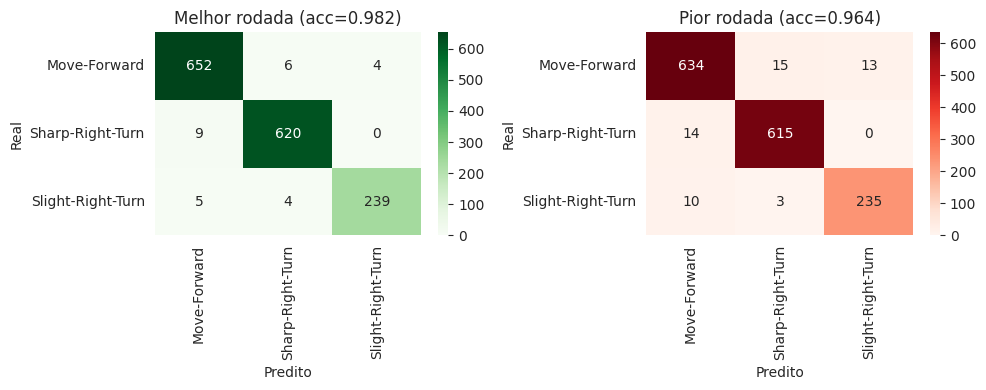

In [17]:
melhor_modelo = resumo.xs(0.7, level="proporcao_treino")["mean"].idxmax()
print("Melhor modelo na proporção 70/30:", melhor_modelo)

chave = (melhor_modelo, 0.7)
fig, eixos = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(extremos[chave]["melhor_cm"], annot=True, fmt="d", cmap="Greens",
            xticklabels=classes, yticklabels=classes, ax=eixos[0])
eixos[0].set_title(f"Melhor rodada (acc={extremos[chave]['melhor_acc']:.3f})")
sns.heatmap(extremos[chave]["pior_cm"], annot=True, fmt="d", cmap="Reds",
            xticklabels=classes, yticklabels=classes, ax=eixos[1])
eixos[1].set_title(f"Pior rodada (acc={extremos[chave]['pior_acc']:.3f})")
for eixo in eixos:
    eixo.set_xlabel("Predito")
    eixo.set_ylabel("Real")
plt.tight_layout()
plt.show()

Análise das matrizes de confusão:

As matrizes de confusão apresentadas correspondem à **melhor** e à **pior** rodada obtidas pelo classificador de melhor desempenho na proporção de treinamento **70/30**. A matriz da esquerda representa a execução com maior acurácia (**98,2%**), enquanto a da direita corresponde à menor acurácia observada (**96,4%**) entre as 100 rodadas.

Em ambas as matrizes, observa-se que a maior parte das amostras foi corretamente classificada, evidenciado pelos elevados valores presentes na diagonal principal. Isso indica que o classificador apresentou excelente capacidade de discriminar as três classes do problema.

A classe **Move-Forward** foi a que concentrou o maior número absoluto de amostras e, consequentemente, também apresentou a maior quantidade de erros de classificação. Entretanto, mesmo na pior rodada, a maior parte dessas amostras continuou sendo corretamente identificada.

A classe **Sharp-Right-Turn** apresentou desempenho bastante consistente, com poucos erros de classificação, principalmente em relação à classe **Slight-Right-Turn**.

Já a classe **Slight-Right-Turn** foi a que apresentou menor quantidade de amostras e também manteve uma elevada taxa de acertos nas duas execuções, ocorrendo apenas poucas confusões com as demais classes.

Comparando a melhor e a pior rodada, percebe-se que a diferença entre elas é relativamente pequena. Na pior execução houve apenas um aumento no número de classificações incorretas, principalmente envolvendo a classe **Move-Forward**, o que reduziu a acurácia global em aproximadamente **1,8 pontos percentuais**. Esse comportamento reforça a estabilidade do classificador ao longo das 100 execuções realizadas.

A análise acima foi feita para destacar o algoritmo vencedor, entretanto ainda temos as amtrizes de confusão dos outros classificadores avaliados:

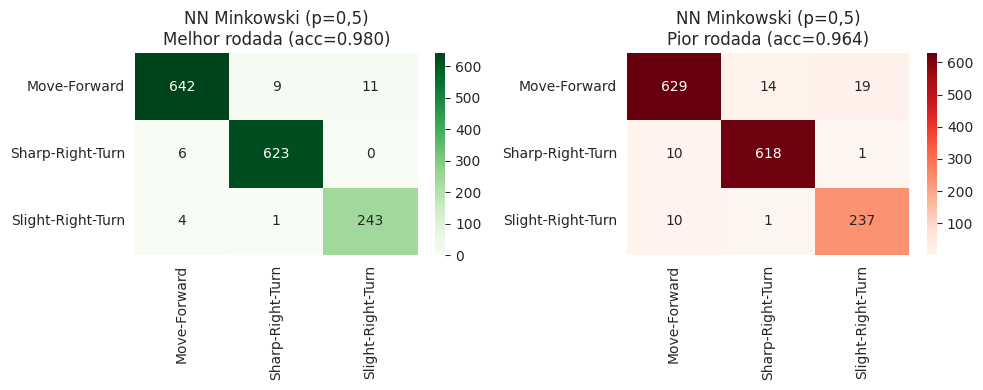

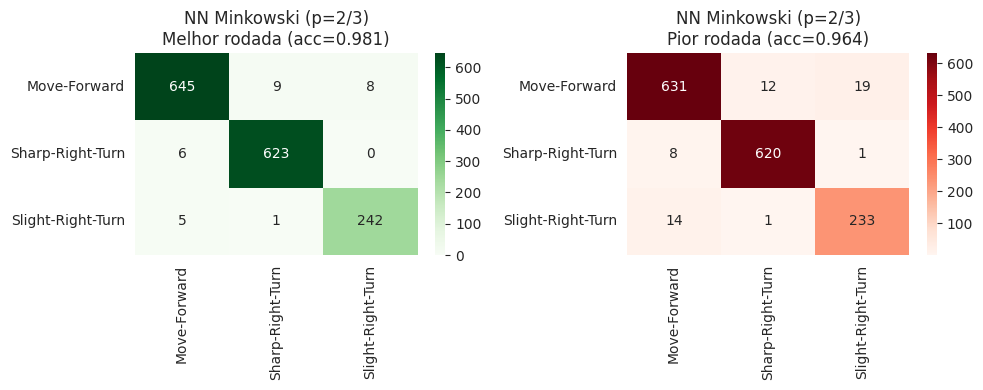

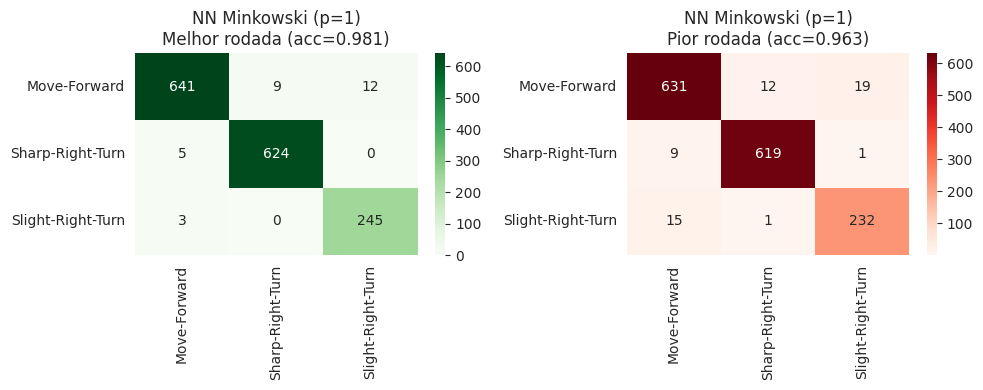

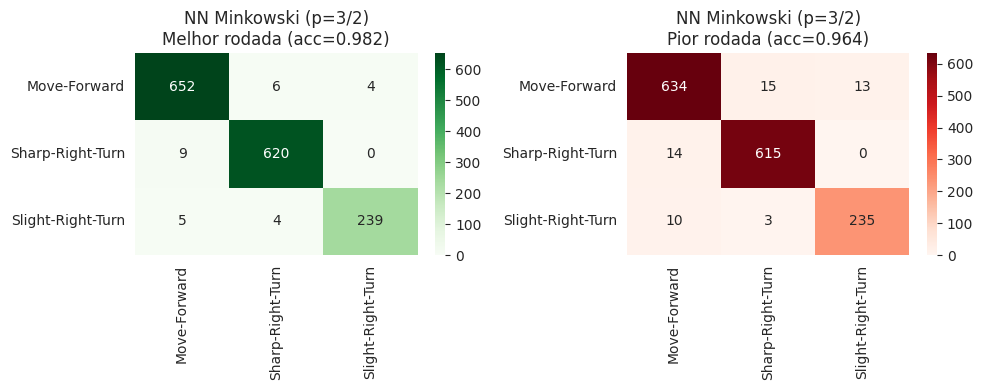

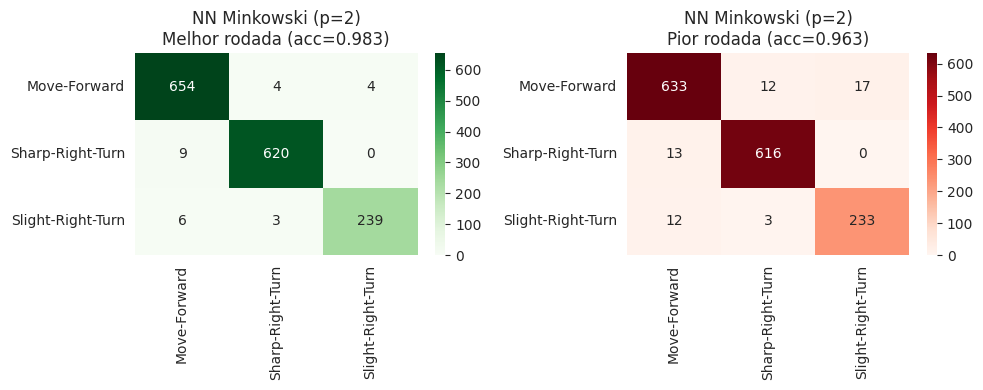

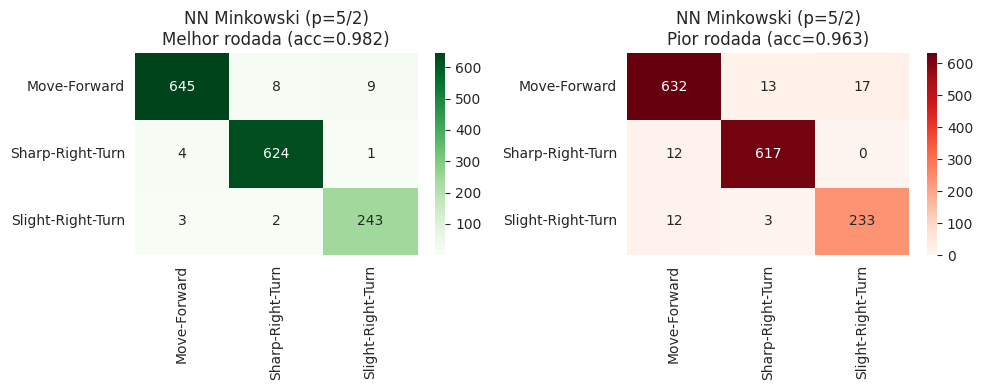

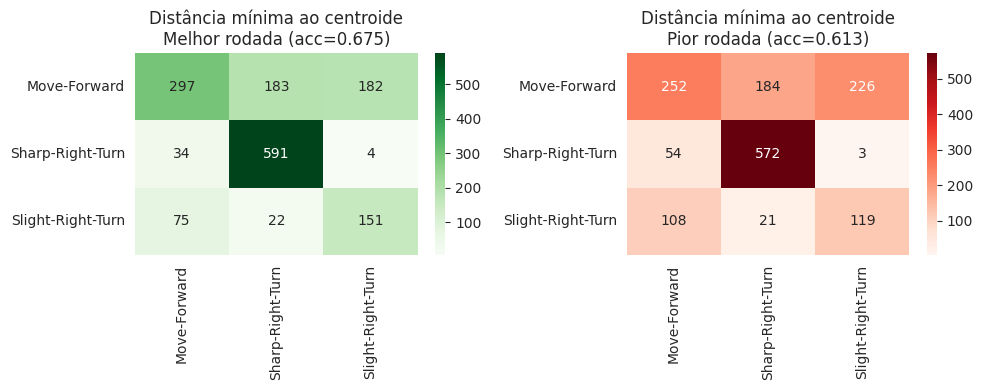

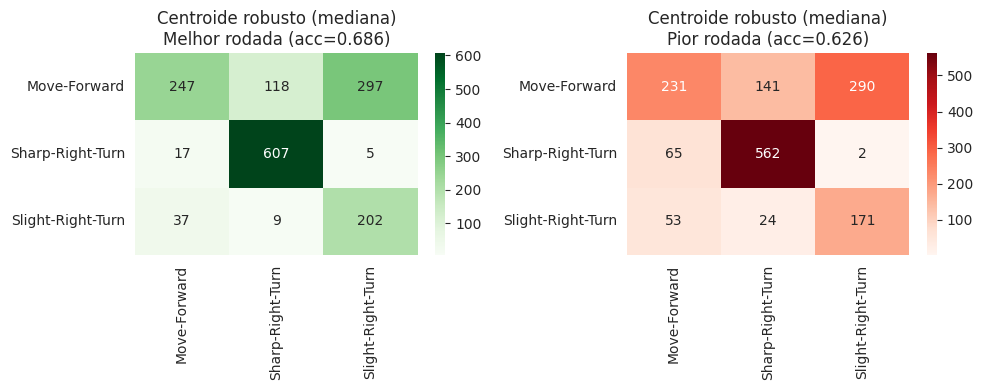

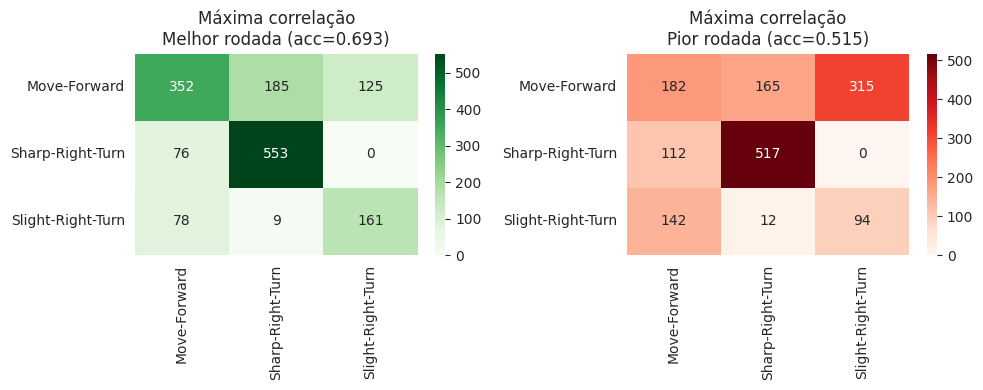

In [18]:
proporcao_ref = 0.7
nomes_modelos = resultados["modelo"].unique()

for nome_modelo in nomes_modelos:
    chave = (nome_modelo, proporcao_ref)
    if chave not in extremos:
        continue
    fig, eixos = plt.subplots(1, 2, figsize=(10, 4))
    sns.heatmap(extremos[chave]["melhor_cm"], annot=True, fmt="d", cmap="Greens",
                xticklabels=classes, yticklabels=classes, ax=eixos[0])
    eixos[0].set_title(f"{nome_modelo}\nMelhor rodada (acc={extremos[chave]['melhor_acc']:.3f})")
    sns.heatmap(extremos[chave]["pior_cm"], annot=True, fmt="d", cmap="Reds",
                xticklabels=classes, yticklabels=classes, ax=eixos[1])
    eixos[1].set_title(f"{nome_modelo}\nPior rodada (acc={extremos[chave]['pior_acc']:.3f})")
    plt.tight_layout()
    plt.show()

Análise dos demais métodos (NN com diferentes métricas de Minkowski e classificadores de protótipo)

**NN com distância de Minkowski variando p**

Testamos o classificador do vizinho mais próximo (NN) usando a distância de Minkowski com seis valores de p (0,5, 2/3, 1, 3/2, 2 e 5/2), e o desempenho se mostra bastante estável e alto em todos os casos, com acurácia entre 0,980 e 0,983 na melhor rodada e entre 0,963 e 0,964 na pior. Isso já mostra que, pelo menos para essa base, o formato específico da métrica de distância (mais próxima da Manhattan em p=1, Euclidiana em p=2, ou intermediária nos demais valores) importa pouco, o que faz sentido, já que valores de p entre 0,5 e 5/2 não mudam drasticamente a geometria da distância, apenas o peso relativo dado a diferenças grandes versus pequenas entre os atributos.

Olhando com mais atenção, a acurácia cresce levemente à medida que p vai de 0,5 até 2 (0,980, 0,981, 0,981, 0,982, 0,983), atingindo o melhor resultado na distância Euclidiana (p=2), e cai muito discretamente em p=5/2 (0,982), sugerindo que p=2 é o ponto de melhor equilíbrio entre essas opções, embora a diferença entre o pior e o melhor p seja de apenas 0,003 de acurácia, algo dentro da própria variação entre rodadas.

Em todas as matrizes de confusão, o padrão de erro se repete: a classe Sharp-Right-Turn é praticamente sempre bem classificada (620 a 624 acertos em torno de 629 amostras, em qualquer rodada), enquanto a confusão concentra-se entre Move-Forward e Slight-Right-Turn. Na pior rodada de cada p, esse efeito fica mais evidente, com Move-Forward perdendo de 12 a 19 amostras para Slight-Right-Turn, mais que o dobro do erro observado na melhor rodada. Isso indica que essas duas classes têm sobreposição real no espaço de atributos (provavelmente porque, geometricamente, seguir a parede levemente à direita e mover-se para frente geram leituras de sensores parecidas), e que o NN, mesmo sendo um classificador de fronteira flexível, ainda erra sistematicamente nessa região de sobreposição, independente da métrica de distância escolhida.

**Classificadores baseados em protótipo (distância mínima ao centroide, centroide robusto e máxima correlação)**

Diferente do NN, que compara cada amostra de teste com todos os exemplos de treino, esses três métodos resumem cada classe a um único protótipo (a média, a mediana, ou o próprio vetor usado como referência de correlação) e classificam pela proximidade a esse protótipo. O resultado é uma queda drástica de desempenho frente ao NN: a acurácia da melhor rodada cai para 0,675 (centroide simples), 0,686 (centroide robusto) e 0,693 (máxima correlação), e a da pior rodada despenca ainda mais, para 0,613, 0,626 e apenas 0,515, respectivamente.

As matrizes de confusão mostram por que isso acontece: a classe Move-Forward, que tem o maior número de amostras, é a que mais sofre nesses três métodos, sendo confundida maciçamente com as outras duas classes (por exemplo, na pior rodada da máxima correlação, apenas 182 das 611 amostras de Move-Forward são classificadas corretamente, com 165 indo para Sharp-Right-Turn e 315 para Slight-Right-Turn). Isso é esperado, já que reduzir uma classe inteira a um único ponto (média, mediana ou vetor de referência) ignora toda a variabilidade interna da classe, então quando essa variabilidade é grande (como parece ser o caso de Move-Forward), o protótipo único não consegue representar bem todos os padrões daquela classe.

Entre os três, o centroide robusto (mediana) tem desempenho ligeiramente melhor que o centroide simples nas duas rodadas, o que é coerente com a ideia de que a mediana é menos sensível a outliers do que a média, produzindo um protótipo mais representativo do "centro" real da classe. Já o método de máxima correlação é o mais instável dos três: tem a melhor acurácia na melhor rodada (0,693), mas a pior de longe na pior rodada (0,515), uma queda muito maior que a dos outros dois métodos. Isso provavelmente acontece porque a correlação mede apenas o quão parecido é o padrão (formato) das leituras dos sensores, ignorando a escala/magnitude absoluta dos valores, então duas amostras de classes diferentes podem ter alta correlação entre si mesmo tendo módulos bem diferentes, o que torna esse método mais sujeito a trocas catastróficas de classe quando os padrões de sensores de duas classes têm formato parecido.

### OBS 4 - Desempenho por classe

Vendo se alguma classe é sistematicamente mais fácil ou mais difícil de acertar que as outras, usando a proporção 70/30 como referência.

In [19]:
resumo_por_classe = resultados_por_classe[resultados_por_classe["proporcao_treino"] == 0.7].groupby(
    ["modelo", "classe"]
)["acuracia"].agg(["mean", "std"]).round(4)
resumo_por_classe

mean     std
modelo                        classe                           
Centroide robusto (mediana)   Move-Forward       0.3696  0.0155
                              Sharp-Right-Turn   0.9126  0.0242
                              Slight-Right-Turn  0.7762  0.0306
Distância mínima ao centroide Move-Forward       0.4126  0.0158
                              Sharp-Right-Turn   0.9147  0.0172
                              Slight-Right-Turn  0.5809  0.0386
Máxima correlação             Move-Forward       0.3734  0.0561
                              Sharp-Right-Turn   0.8449  0.0185
                              Slight-Right-Turn  0.5484  0.0618
NN Minkowski (p=0,5)          Move-Forward       0.9653  0.0063
                              Sharp-Right-Turn   0.9838  0.0048
                              Slight-Right-Turn  0.9601  0.0117
NN Minkowski (p=1)            Move-Forward       0.9687  0.0066
                              Sharp-Right-Turn   0.9837  0.0051
                              Slight-Right-Turn  0.9564  0.0123
NN Minkowski (p=2)            Move-Forward       0.9672  0.0064
                              Sharp-Right-Turn   0.9845  0.0049
                              Slight-Right-Turn  0.9580  0.0127
NN Minkowski (p=2/3)          Move-Forward       0.9679  0.0063
                              Sharp-Right-Turn   0.9834  0.0052
                              Slight-Right-Turn  0.9564  0.0119
NN Minkowski (p=3/2)          Move-Forward       0.9684  0.0064
                              Sharp-Right-Turn   0.9844  0.0050
                              Slight-Right-Turn  0.9577  0.0120
NN Minkowski (p=5/2)          Move-Forward       0.9658  0.0067
                              Sharp-Right-Turn   0.9848  0.0048
                              Slight-Right-Turn  0.9573  0.0126

Análise do desempenho por classe

Para complementar a avaliação dos classificadores, foi analisada a **acurácia por classe** utilizando a proporção de treinamento **70/30**. Para cada modelo foram calculadas a **média** e o **desvio padrão** da acurácia em cada uma das três classes ao longo das 100 rodadas.

Os resultados mostram que a classe **Sharp-Right-Turn** foi, de maneira geral, a mais fácil de classificar. Todos os classificadores obtiveram elevadas taxas de acerto nessa classe, destacando-se o **Vizinho Mais Próximo (1-NN)**, que alcançou médias próximas de **98,5%** de acurácia.

As classes **Move-Forward** e **Slight-Right-Turn** apresentaram maior dificuldade de classificação, principalmente para os métodos baseados em centróides e para o classificador de Máxima Correlação. Em especial, o método de **Distância Mínima ao Centróide** e o de **Máxima Correlação** obtiveram acurácias significativamente inferiores nessas duas classes, indicando maior ocorrência de confusões entre elas.

Os classificadores **1-NN**, independentemente da ordem da distância de Minkowski utilizada, apresentaram desempenho elevado e bastante equilibrado entre todas as classes, mantendo acurácias superiores a aproximadamente **95%** em todos os casos. Além disso, os baixos valores de desvio padrão indicam que esse desempenho permaneceu consistente ao longo das 100 execuções.

Esses resultados mostram que existem diferenças na dificuldade de classificação entre as classes do conjunto de dados, sendo **Sharp-Right-Turn** a mais facilmente identificada, enquanto **Move-Forward** e **Slight-Right-Turn** exigem maior capacidade discriminativa por parte dos classificadores.